In [5]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (541909, 8)


In [6]:
print("First 5 rows:")
display(df.head())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
None

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [9]:
# Calculate total amount for each transaction
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Remove cancelled/invalid transactions
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Set the reference date
reference_date = df["InvoiceDate"].max()

# Create RFM features
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

print("RFM analysis created successfully!")
display(rfm.head())

RFM analysis created successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [10]:
print("RFM Descriptive Statistics:")
display(rfm.describe())

RFM Descriptive Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,307.415000
50%,50.000000,2.000000,674.485000
75%,141.000000,5.000000,1661.740000
max,373.000000,209.000000,280206.020000


In [11]:
from sklearn.preprocessing import StandardScaler

# Standardize RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

print("RFM data standardized successfully!")
print("Shape:", rfm_scaled.shape)

RFM data standardized successfully!
Shape: (4338, 3)


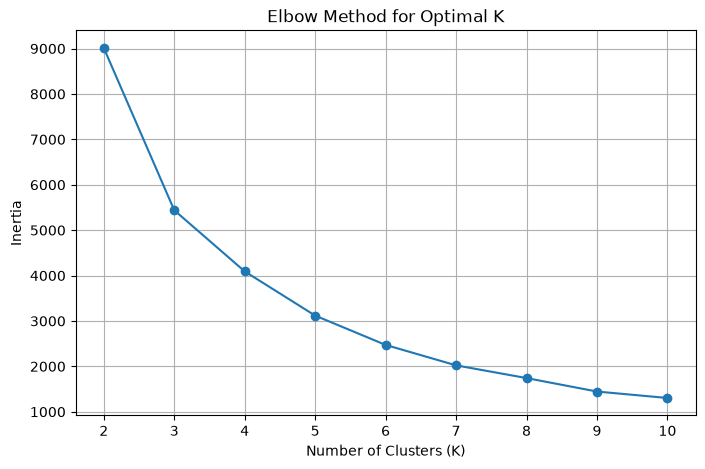

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different numbers of clusters
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

In [13]:
import pandas as pd

# Load the dataset
df = pd.read_excel("Online Retail.xlsx")

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled/negative transactions
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Create total purchase amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Set a reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM features
customer_data = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

print("RFM customer data created successfully!")
print(customer_data.head())
print("\nShape:", customer_data.shape)

RFM customer data created successfully!
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40

Shape: (4338, 4)


In [14]:
from sklearn.preprocessing import StandardScaler

# Select RFM features
features = ['Recency', 'Frequency', 'Monetary']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_data[features])

print("Data standardized successfully!")
print("Scaled data shape:", X_scaled.shape)

Data standardized successfully!
Scaled data shape: (4338, 3)


In [15]:


from sklearn.cluster import KMeans

# Apply K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit the model
kmeans.fit(X_scaled)

# Get cluster labels
customer_data['Cluster'] = kmeans.labels_

# Display the customer segments
customer_data.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [16]:
# Calculate average RFM values for each cluster
cluster_profile = customer_data.groupby('Cluster')[features].mean().round(2)

print("Customer Segment Profile:")
display(cluster_profile)

Customer Segment Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,43.95,3.65,1339.07
1,248.56,1.55,478.11
2,15.67,21.29,12831.74
3,6.50,120.50,55312.69
4,7.67,42.83,190863.46


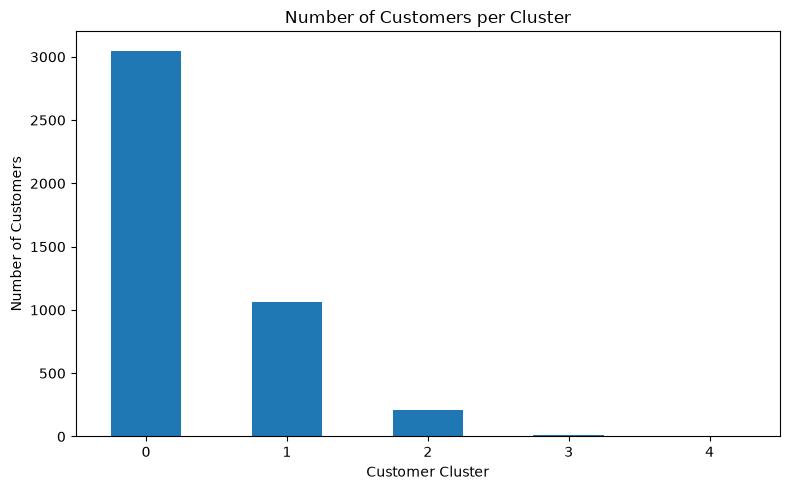

In [17]:
import matplotlib.pyplot as plt

# Count customers in each cluster
cluster_counts = customer_data['Cluster'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

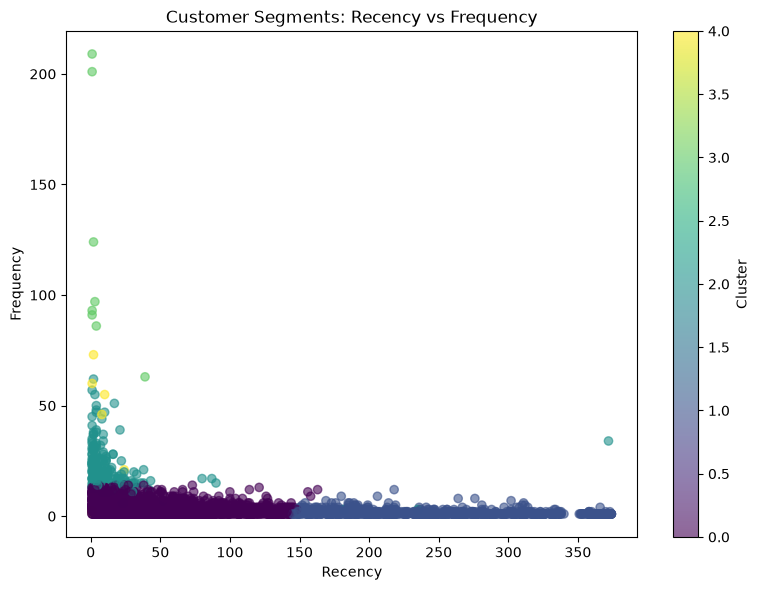

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    customer_data['Recency'],
    customer_data['Frequency'],
    c=customer_data['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.colorbar(label='Cluster')

plt.tight_layout()
plt.show()

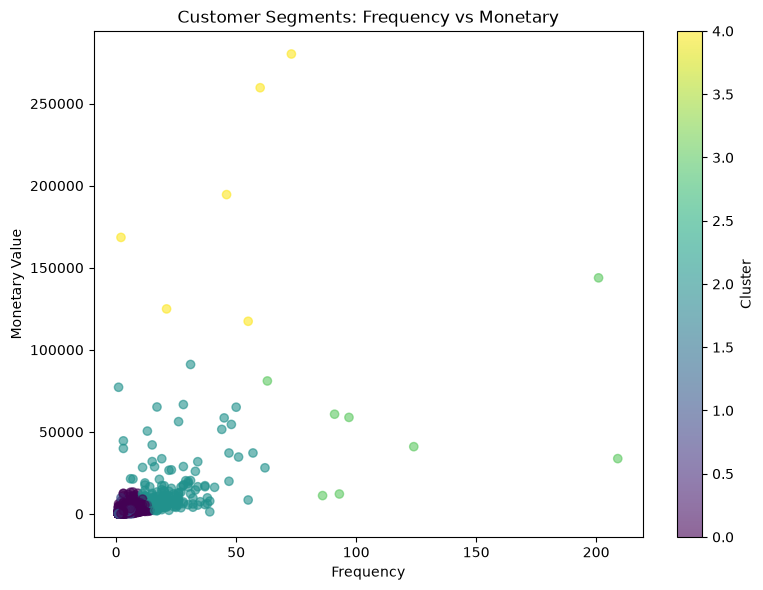

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    customer_data['Frequency'],
    customer_data['Monetary'],
    c=customer_data['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.colorbar(label='Cluster')

plt.tight_layout()
plt.show()

In [20]:
# Display the final cluster profile
cluster_profile = customer_data.groupby('Cluster')[features].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.95,3.65,1339.07
1,248.56,1.55,478.11
2,15.67,21.29,12831.74
3,6.50,120.50,55312.69
4,7.67,42.83,190863.46


## Customer Segment Analysis

The scatter plot shows different customer segments based on their purchase frequency and monetary value.

- Customers with higher frequency and monetary value represent more valuable customers.
- Customers with lower frequency and monetary value represent less active customers.
- The clustering helps identify groups of customers with similar purchasing behavior.
- These segments can be used to develop targeted marketing strategies.

In [21]:
import matplotlib.pyplot as plt

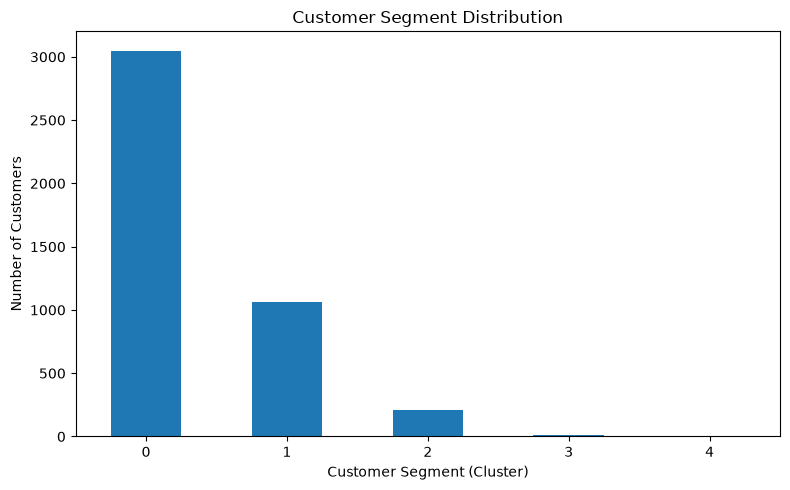

In [22]:
plt.figure(figsize=(8, 5))

customer_data['Cluster'].value_counts().sort_index().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment (Cluster)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
customer_data.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster'], dtype='str')

In [25]:
cluster_summary = customer_data.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})

cluster_summary.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,43.95,3.65,1339.07
1,248.56,1.55,478.11
2,15.67,21.29,12831.74
3,6.50,120.50,55312.69
4,7.67,42.83,190863.46


In [27]:
import seaborn as sns

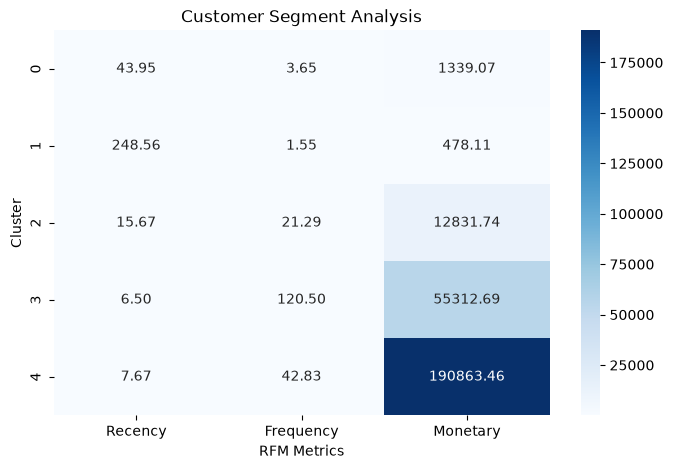

In [28]:
plt.figure(figsize=(8, 5))

sns.heatmap(cluster_summary, annot=True, fmt='.2f', cmap='Blues')

plt.title('Customer Segment Analysis')
plt.xlabel('RFM Metrics')
plt.ylabel('Cluster')

plt.show()

In [29]:


cluster_counts = customer_data['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    3049
1    1062
2     213
3       8
4       6
Name: count, dtype: int64

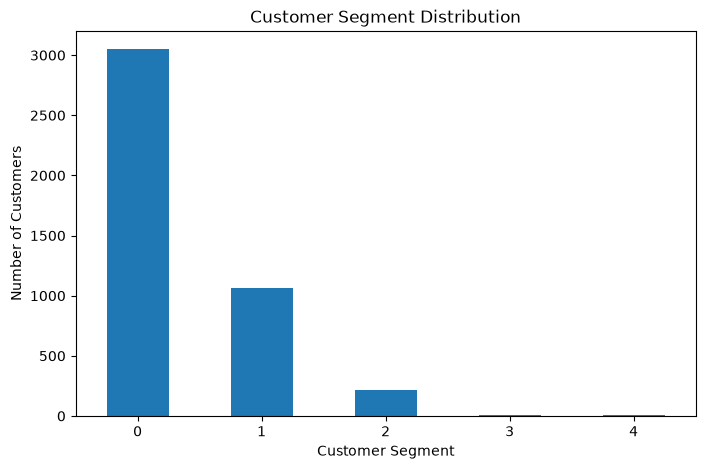

In [30]:


plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

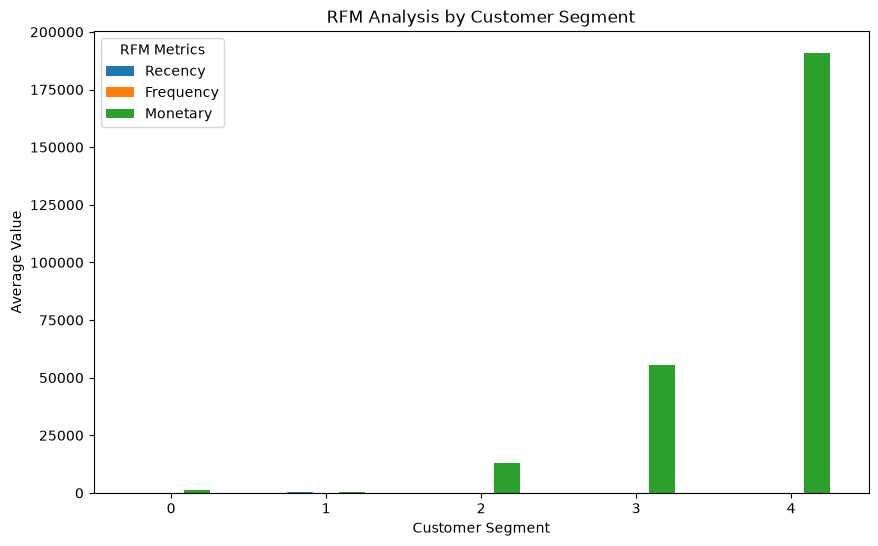

In [32]:
cluster_summary.plot(kind='bar', figsize=(10, 6))

plt.title('RFM Analysis by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Value')
plt.xticks(rotation=0)

plt.legend(title='RFM Metrics')
plt.show()

In [33]:
customer_data.to_csv('customer_segmentation_results.csv', index=False)

print("Customer segmentation results saved successfully!")

Customer segmentation results saved successfully!


In [34]:
cluster_profile = customer_data.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'})

cluster_profile.round(2)

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.95,3.65,1339.07,3049
1,248.56,1.55,478.11,1062
2,15.67,21.29,12831.74,213
3,6.50,120.50,55312.69,8
4,7.67,42.83,190863.46,6


In [35]:
highest_value_cluster = cluster_profile['Monetary'].idxmax()

print("Highest-value customer segment:", highest_value_cluster)

Highest-value customer segment: 4


In [36]:
cluster_profile.round(2)

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.95,3.65,1339.07,3049
1,248.56,1.55,478.11,1062
2,15.67,21.29,12831.74,213
3,6.50,120.50,55312.69,8
4,7.67,42.83,190863.46,6


In [37]:

print("Customer Segmentation Analysis Completed")
print("--------------------------------------")
print(f"Total Customers: {len(customer_data)}")
print(f"Number of Customer Segments: {customer_data['Cluster'].nunique()}")
print(f"Highest-Value Segment: Cluster {highest_value_cluster}")

Customer Segmentation Analysis Completed
--------------------------------------
Total Customers: 4338
Number of Customer Segments: 5
Highest-Value Segment: Cluster 4


## Final Conclusions

- Customer segmentation was performed using RFM (Recency, Frequency, Monetary) analysis.
- K-Means clustering was used to group customers based on their purchasing behavior.
- The clusters represent customers with different levels of engagement and spending.
- The segment distribution chart shows the number of customers in each group.
- These customer segments can help businesses design targeted marketing campaigns and improve customer retention.
- RFM analysis combined with clustering provides useful insights for data-driven customer relationship management.